In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "student_files" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from texturelab.config import FeatureConfig, GaborConfig
from texturelab.data import read_manifest
from texturelab.supplied import load_image, rgb2gray, nms_nearest
from texturelab.gabor_branch import make_gabor_bank, gabor_energy_maps
from texturelab.edge_branch import detect_edges
from texturelab.features import extract_local_features

config = FeatureConfig(
    gabor=GaborConfig(
        frequencies=(0.08, 0.16, 0.28),
        phases=(0.0,),  # Radian offsets applied to the sine carrier.
        kernel_size=15,
        pool_size=9,
    )
)
mvtec = read_manifest(ROOT / "manifests" / "mvtec_textures.csv")
materials = ["carpet", "grid", "leather", "tile", "wood"]
examples = {}
for material in materials:
    record = next(r for r in mvtec if r.split == "train" and r.material == material)
    sample = load_image(record.path, (96, 96))
    examples[material] = sample

image = examples["wood"]
gray = rgb2gray(image)



print("RGB range:", (float(image.min()), float(image.max())))
print("gray range:", (float(gray.min()), float(gray.max())), "shape:", gray.shape)
bank = make_gabor_bank(config.gabor)


RGB range: (0.2235294133424759, 0.8392156958580017)
gray range: (0.3022839426994324, 0.6816494464874268) shape: (96, 96)


## Gabor parameter study on synthetic data
Helpers: a sinusoidal grating generator and a function that returns the energy map of a single Gabor filter.

In [2]:
from dataclasses import replace

plt.rcParams.update({"font.size": 10, "axes.titlesize": 10, "figure.dpi": 120})


def stripes(size, freq, angle=0.0, phase=0.0):
    """Sinusoidal grating in [0, 1]; angle uses the same convention as the Gabor bank."""
    y, x = np.mgrid[0:size, 0:size].astype(np.float32)
    return 0.5 + 0.5 * np.sin(2 * np.pi * freq * (np.cos(angle) * x + np.sin(angle) * y) + phase)


def single_filter_energy(img, pool_size=1, **params):
    """Energy map of one Gabor filter built from the default config with a few overrides."""
    bank = make_gabor_bank(replace(GaborConfig(), **params))
    return gabor_energy_maps(img, bank, pool_size=pool_size)[:, :, 0]


def show(ax, img, title, cmap="gray", vmin=None, vmax=None):
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

### Frequency
Vertical stripes at three frequencies; each filter lights up only the band whose stripe frequency matches its own.

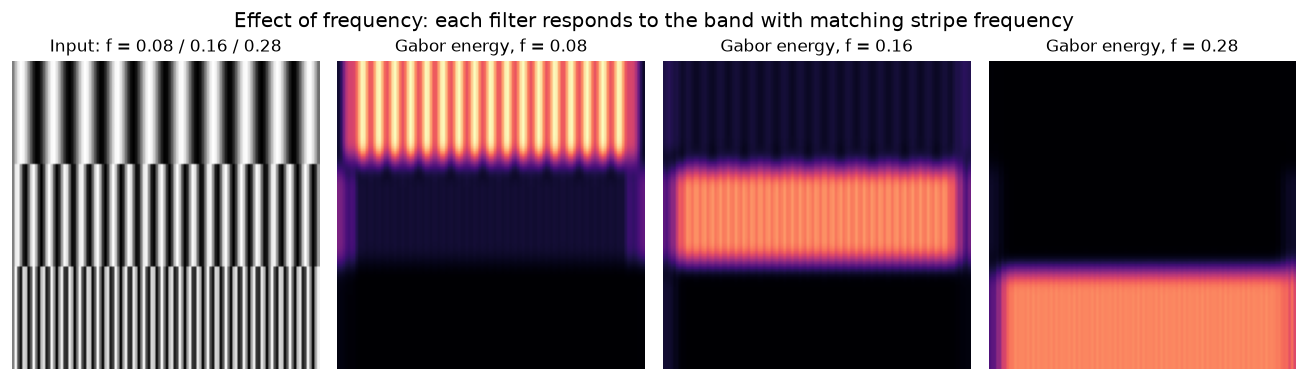

In [3]:
freqs = [0.08, 0.16, 0.28]

# Three horizontal bands of vertical stripes, one per frequency (top to bottom)
band = 40
freq_img = np.vstack([stripes(3 * band, f)[:band] for f in freqs])

fig, axes = plt.subplots(1, 4, figsize=(11, 3.2))
show(axes[0], freq_img, "Input: f = 0.08 / 0.16 / 0.28")
maps = [single_filter_energy(freq_img, pool_size=9, frequencies=(f,), orientations=(0.0,)) for f in freqs]
vmax = max(m.max() for m in maps)
for ax, f, m in zip(axes[1:], freqs, maps):
    show(ax, m, f"Gabor energy, f = {f}", cmap="magma", vmin=0, vmax=vmax)
fig.suptitle("Effect of frequency: each filter responds to the band with matching stripe frequency")
fig.tight_layout()
plt.show()

### Orientation
Stripes at four orientations; each filter responds only to the quadrant with matching orientation.

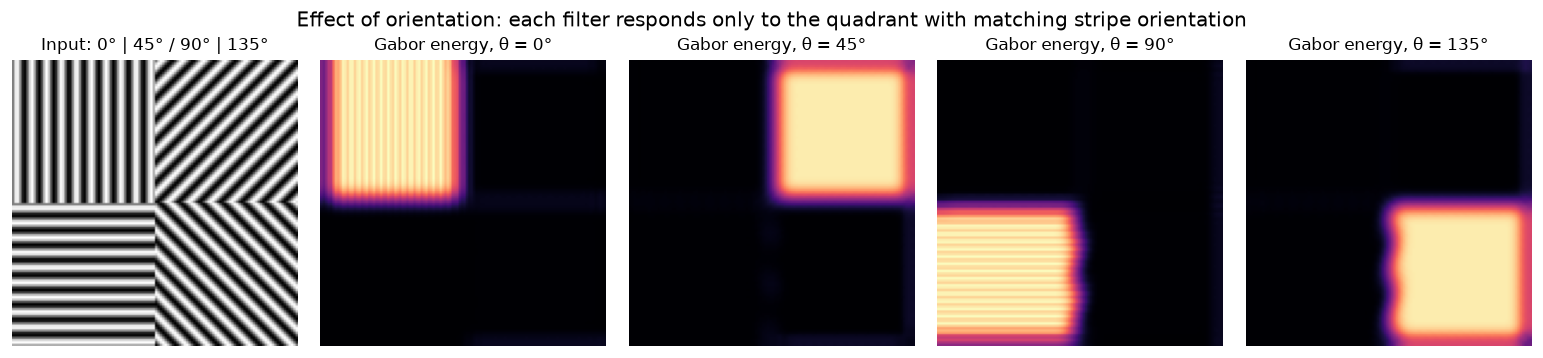

In [4]:
angles = [0, 45, 90, 135]
half = 60

# Four quadrants of stripes at 0°, 45°, 90°, 135°
quads = [stripes(half, 0.16, np.deg2rad(a)) for a in angles]
orient_img = np.block([[quads[0], quads[1]], [quads[2], quads[3]]])

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
show(axes[0], orient_img, "Input: 0° | 45° / 90° | 135°")
maps = [single_filter_energy(orient_img, pool_size=9, frequencies=(0.16,), orientations=(np.deg2rad(a),)) for a in angles]
vmax = max(m.max() for m in maps)
for ax, a, m in zip(axes[1:], angles, maps):
    show(ax, m, f"Gabor energy, θ = {a}°", cmap="magma", vmin=0, vmax=vmax)
fig.suptitle("Effect of orientation: each filter responds only to the quadrant with matching stripe orientation")
fig.tight_layout()
plt.show()

### Phase
No pooling (). The odd (sine) filter peaks on step edges, the even (cosine) filter peaks at the centre of thin lines.

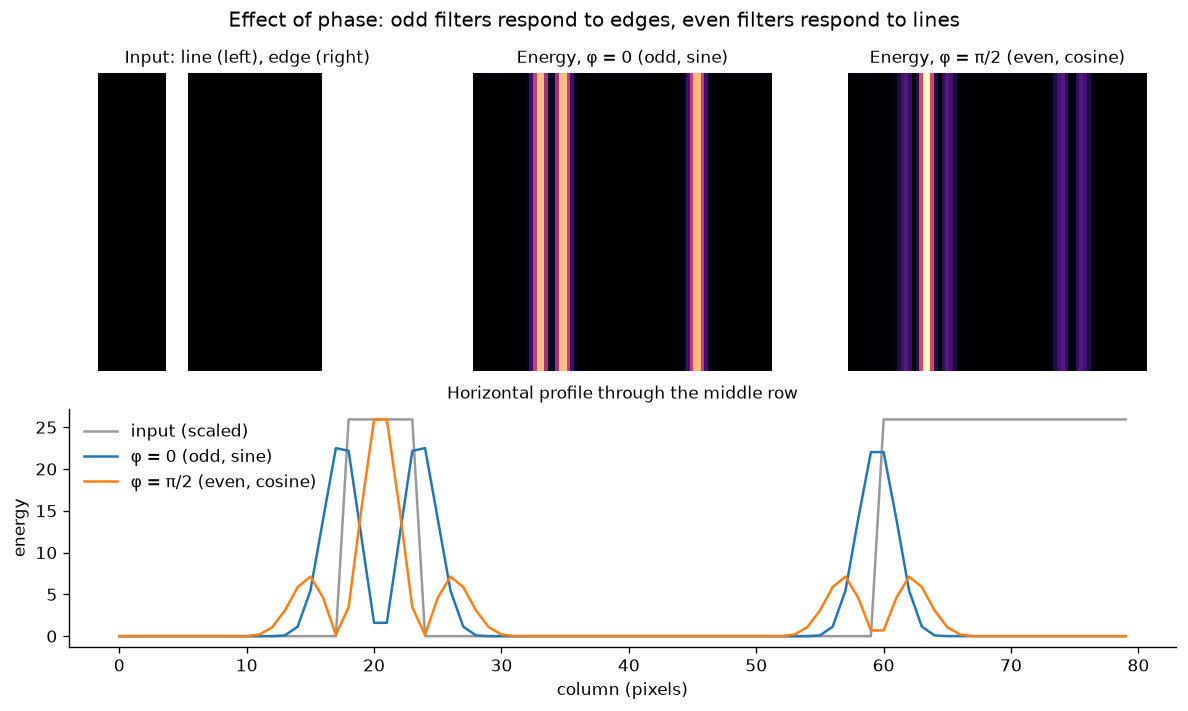

In [5]:
size = 80
phase_img = np.zeros((size, size), dtype=np.float32)
phase_img[:, 18:24] = 1.0   # thin bright line (left)
phase_img[:, 60:] = 1.0     # step edge (right)

phases = {"φ = 0 (odd, sine)": 0.0, "φ = π/2 (even, cosine)": np.pi / 2}
maps = {name: single_filter_energy(phase_img, pool_size=1, frequencies=(0.08,), orientations=(0.0,), phases=(p,))
        for name, p in phases.items()}

fig, axes = plt.subplot_mosaic([["img", "odd", "even"], ["profile", "profile", "profile"]],
                               figsize=(10, 6), height_ratios=[1, 0.8])
show(axes["img"], phase_img, "Input: line (left), edge (right)")
vmax = max(m.max() for m in maps.values())
for key, (name, m) in zip(["odd", "even"], maps.items()):
    show(axes[key], m, f"Energy, {name}", cmap="magma", vmin=0, vmax=vmax)

row = size // 2
axes["profile"].plot(phase_img[row] * vmax, color="0.6", label="input (scaled)")
for name, m in maps.items():
    axes["profile"].plot(m[row], label=name)
axes["profile"].set_xlabel("column (pixels)")
axes["profile"].set_ylabel("energy")
axes["profile"].set_title("Horizontal profile through the middle row")
axes["profile"].legend(frameon=False)
axes["profile"].spines[["top", "right"]].set_visible(False)
fig.suptitle("Effect of phase: odd filters respond to edges, even filters respond to lines")
fig.tight_layout()
plt.show()

### Pooling size in 
Noisy vertical stripes with a small 8×8 defect and a region of horizontal stripes. Larger pooling removes the ripple and noise but also washes out the small defect.

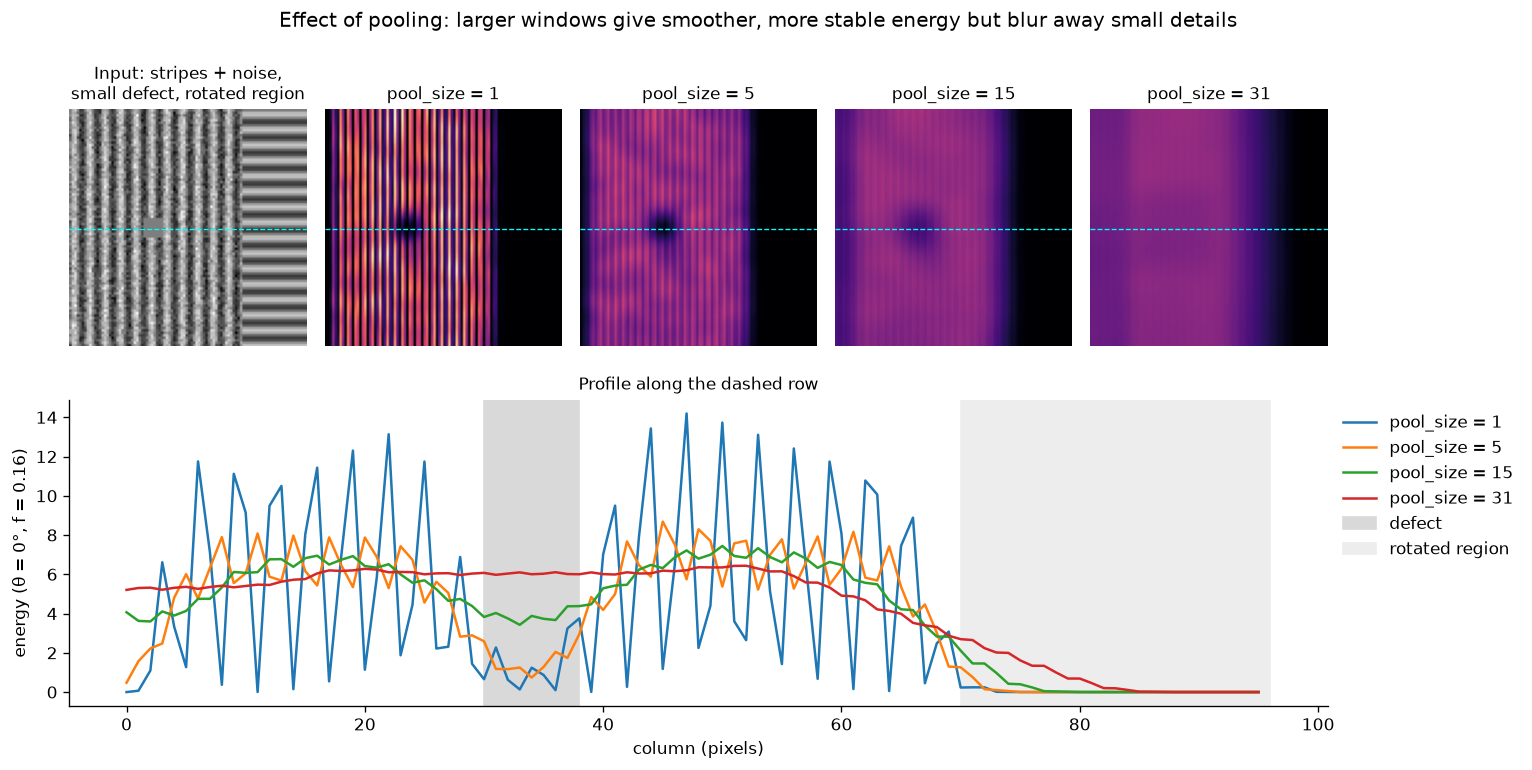

In [6]:
size = 96
rng = np.random.default_rng(0)
pool_img = stripes(size, 0.16) + 0.15 * rng.standard_normal((size, size))
pool_img[44:52, 30:38] = 0.5          # small 8x8 defect: stripes erased
pool_img[:, 70:] = stripes(size, 0.16, np.pi / 2)[:, 70:]  # region with horizontal stripes

pool_sizes = [1, 5, 15, 31]
maps = [single_filter_energy(pool_img, pool_size=p, frequencies=(0.16,), orientations=(0.0,)) for p in pool_sizes]

fig, axes = plt.subplot_mosaic([["img"] + [f"p{p}" for p in pool_sizes], ["profile"] * 5],
                               figsize=(13, 6.5), height_ratios=[1, 0.9])
show(axes["img"], pool_img, "Input: stripes + noise,\nsmall defect, rotated region")
vmax = max(m.max() for m in maps)
for p, m in zip(pool_sizes, maps):
    show(axes[f"p{p}"], m, f"pool_size = {p}", cmap="magma", vmin=0, vmax=vmax)

row = 48  # passes through the small defect
for ax in [axes[f"p{p}"] for p in pool_sizes] + [axes["img"]]:
    ax.axhline(row, color="cyan", lw=0.8, ls="--")
for p, m in zip(pool_sizes, maps):
    axes["profile"].plot(m[row], label=f"pool_size = {p}")
axes["profile"].axvspan(30, 38, color="0.85", label="defect")
axes["profile"].axvspan(70, size, color="0.93", label="rotated region")
axes["profile"].set_xlabel("column (pixels)")
axes["profile"].set_ylabel("energy (θ = 0°, f = 0.16)")
axes["profile"].set_title("Profile along the dashed row")
axes["profile"].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
axes["profile"].spines[["top", "right"]].set_visible(False)
fig.suptitle("Effect of pooling: larger windows give smoother, more stable energy but blur away small details")
fig.tight_layout()
plt.show()